In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/nyc_housing_base.csv')

# About Data

In [ ]:
df.sample(5)

,borough_x,block,lot,sale_price,zip_code,borough_y,yearbuilt,lotarea,bldgarea,resarea,comarea,unitsres,unitstotal,numfloors,latitude,longitude,landuse,bldgclass,building_age
28448,4,13575,29,850000,11422.0,QN,1925.0,5000.0,1628.0,1628.0,0.0,2.0,2.0,2.5,40.661946,-73.735469,1.0,B3,100.0
8619,2,5735,255,1525000,10463.0,BX,1925.0,4000.0,3534.0,2865.0,0.0,1.0,1.0,2.5,40.881497,-73.912847,1.0,A1,100.0
11836,3,5700,25,1600000,11220.0,BK,1925.0,2003.0,2916.0,2156.0,0.0,2.0,2.0,2.0,40.635763,-74.007393,1.0,B1,100.0
28164,4,3526,117,1250000,11385.0,BK,1930.0,2500.0,2400.0,0.0,2400.0,0.0,1.0,1.0,40.668412,-73.908923,5.0,K1,95.0
13104,3,1903,10,4250000,11205.0,BK,1901.0,2000.0,2560.0,1920.0,0.0,3.0,3.0,3.0,40.692493,-73.967416,2.0,C0,124.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34439 entries, 0 to 34438
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   borough_x     34439 non-null  int64  
 1   block         34439 non-null  int64  
 2   lot           34439 non-null  int64  
 3   sale_price    34439 non-null  int64  
 4   zip_code      34423 non-null  float64
 5   borough_y     34439 non-null  object 
 6   yearbuilt     34439 non-null  float64
 7   lotarea       34439 non-null  float64
 8   bldgarea      34439 non-null  float64
 9   resarea       34251 non-null  float64
 10  comarea       34251 non-null  float64
 11  unitsres      34439 non-null  float64
 12  unitstotal    34439 non-null  float64
 13  numfloors     34396 non-null  float64
 14  latitude      34433 non-null  float64
 15  longitude     34433 non-null  float64
 16  landuse       34436 non-null  float64
 17  bldgclass     34439 non-null  object 
 18  building_age  34439 non-nu

In [ ]:
df.shape

(34439, 19)

# data Cleaning

In [ ]:
df.isnull().sum()

,0
borough_x,0
block,0
lot,0
sale_price,0
zip_code,16
borough_y,0
yearbuilt,0
lotarea,0
bldgarea,0
resarea,188


In [ ]:
df.duplicated().sum()

np.int64(1003)

In [ ]:
df[df.duplicated()].shape

(1003, 19)

In [ ]:
df[df.duplicated]

,borough_x,block,lot,sale_price,zip_code,borough_y,yearbuilt,lotarea,bldgarea,resarea,comarea,unitsres,unitstotal,numfloors,latitude,longitude,landuse,bldgclass,building_age
90,1,720,74,1135000,10011.0,MN,1857.0,2172.0,6349.0,6349.0,0.0,10.0,10.0,5.0,40.747138,-74.003587,2.0,C6,168.0
129,1,765,59,791134,10011.0,MN,1901.0,2581.0,9985.0,9985.0,0.0,17.0,17.0,5.0,40.740287,-74.000278,2.0,C6,124.0
130,1,765,59,791134,10011.0,MN,1901.0,2581.0,9985.0,9985.0,0.0,17.0,17.0,5.0,40.740287,-74.000278,2.0,C6,124.0
178,1,748,1,154988,10011.0,QN,1968.0,9783.0,1740.0,0.0,1740.0,0.0,1.0,1.0,40.753328,-73.911178,7.0,G4,57.0
182,1,748,1,117111,10011.0,QN,1968.0,9783.0,1740.0,0.0,1740.0,0.0,1.0,1.0,40.753328,-73.911178,7.0,G4,57.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30606,4,1238,40,310000,11377.0,BK,1910.0,2700.0,7400.0,7400.0,0.0,8.0,8.0,4.0,40.673278,-73.954465,2.0,C1,115.0
30624,4,1340,1,350000,11377.0,QN,1963.0,35360.0,136944.0,136944.0,0.0,159.0,160.0,6.0,40.741691,-73.901886,3.0,D4,62.0
30927,5,2833,31,262500,10305.0,SI,1964.0,77740.0,146640.0,146640.0,0.0,122.0,122.0,9.0,40.611061,-74.060238,3.0,D4,61.0
31191,5,327,60,175000,10301.0,SI,1967.0,75000.0,127800.0,127800.0,0.0,143.0,143.0,9.0,40.618975,-74.107018,3.0,D4,58.0


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.shape

(33436, 19)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
borough_x,0
block,0
lot,0
sale_price,0
zip_code,16
borough_y,0
yearbuilt,0
lotarea,0
bldgarea,0
resarea,184


In [ ]:
corr_matrix=df.corr(numeric_only=True)

In [ ]:
print(corr_matrix['sale_price'].sort_values(ascending=False))

sale_price      1.000000
building_age    0.132110
landuse         0.119969
latitude        0.009640
numfloors      -0.017487
comarea        -0.022395
lotarea        -0.040852
lot            -0.048628
bldgarea       -0.074661
resarea        -0.087753
zip_code       -0.088683
unitstotal     -0.114162
unitsres       -0.115728
longitude      -0.116816
yearbuilt      -0.132110
borough_x      -0.196035
block          -0.202393
Name: sale_price, dtype: float64


In [ ]:
corr_matrix.sample(5)

,borough_x,block,lot,sale_price,zip_code,yearbuilt,lotarea,bldgarea,resarea,comarea,unitsres,unitstotal,numfloors,latitude,longitude,landuse,building_age
zip_code,0.567284,0.551687,-0.030485,-0.088683,1.000000,-0.011752,0.062308,-0.026187,-0.029411,-0.011770,-0.020140,-0.021607,-0.258636,-0.160394,0.464920,-0.134709,0.011752
landuse,-0.224271,-0.240748,-0.037167,0.119969,-0.134709,0.016677,0.028013,0.164675,0.182459,0.103744,0.190039,0.192514,0.312560,0.163221,-0.052877,1.000000,-0.016677
bldgarea,-0.046974,0.007602,0.014654,-0.074661,-0.026187,0.118642,0.619211,1.000000,0.987653,0.873418,0.928138,0.929237,0.591184,0.098211,0.087086,0.164675,-0.118642
building_age,-0.181699,-0.120692,-0.094370,0.132110,0.011752,-1.000000,-0.038282,-0.118642,-0.125444,-0.077645,-0.130370,-0.130006,-0.133361,0.100289,0.070222,-0.016677,1.000000
longitude,0.070136,0.506557,-0.031827,-0.116816,0.464920,-0.070222,0.068408,0.087086,0.082679,0.086803,0.073516,0.072714,-0.060488,0.507821,1.000000,-0.052877,0.070222


In [ ]:
df.fillna(df['landuse'].mode()[0],inplace=True)

In [ ]:
df_final = df[['building_age','landuse','borough_x','block','sale_price']]

In [ ]:
df_final.shape

(33436, 5)

In [ ]:
df_final.isnull().sum()

,0
building_age,0
landuse,0
borough_x,0
block,0
sale_price,0


In [ ]:
df_final[df_final.duplicated()]

,building_age,landuse,borough_x,block,sale_price
118,70.0,1.0,1,745,625000
332,124.0,4.0,1,770,4500000
337,135.0,4.0,1,770,4500000
1555,126.0,2.0,1,1908,1447850
1574,125.0,2.0,1,1831,9962377
...,...,...,...,...,...
34114,126.0,1.0,5,215,400000
34278,115.0,1.0,5,740,773870
34384,4.0,1.0,5,7094,982611
34388,4.0,1.0,5,7094,967338


In [ ]:
df_final.drop_duplicates(inplace=True)

/tmp/ipykernel_21333/3175917877.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final.drop_duplicates(inplace=True)


In [ ]:
df_final.shape

(33163, 5)

In [ ]:
df_final.duplicated().sum()

np.int64(0)

In [ ]:
df_final.sample(5)

,building_age,landuse,borough_x,block,sale_price
9429,98.0,2.0,2,3777,995000
4910,43.0,1.0,1,1524,1675000
18201,80.0,1.0,3,7423,285000
25483,84.0,3.0,4,9755,145000
14180,105.0,1.0,3,4154,1078000


In [ ]:
df_final.skew()

,0
building_age,-0.555693
landuse,2.133512
borough_x,-0.391173
block,0.944742
sale_price,3.398422


#EDA

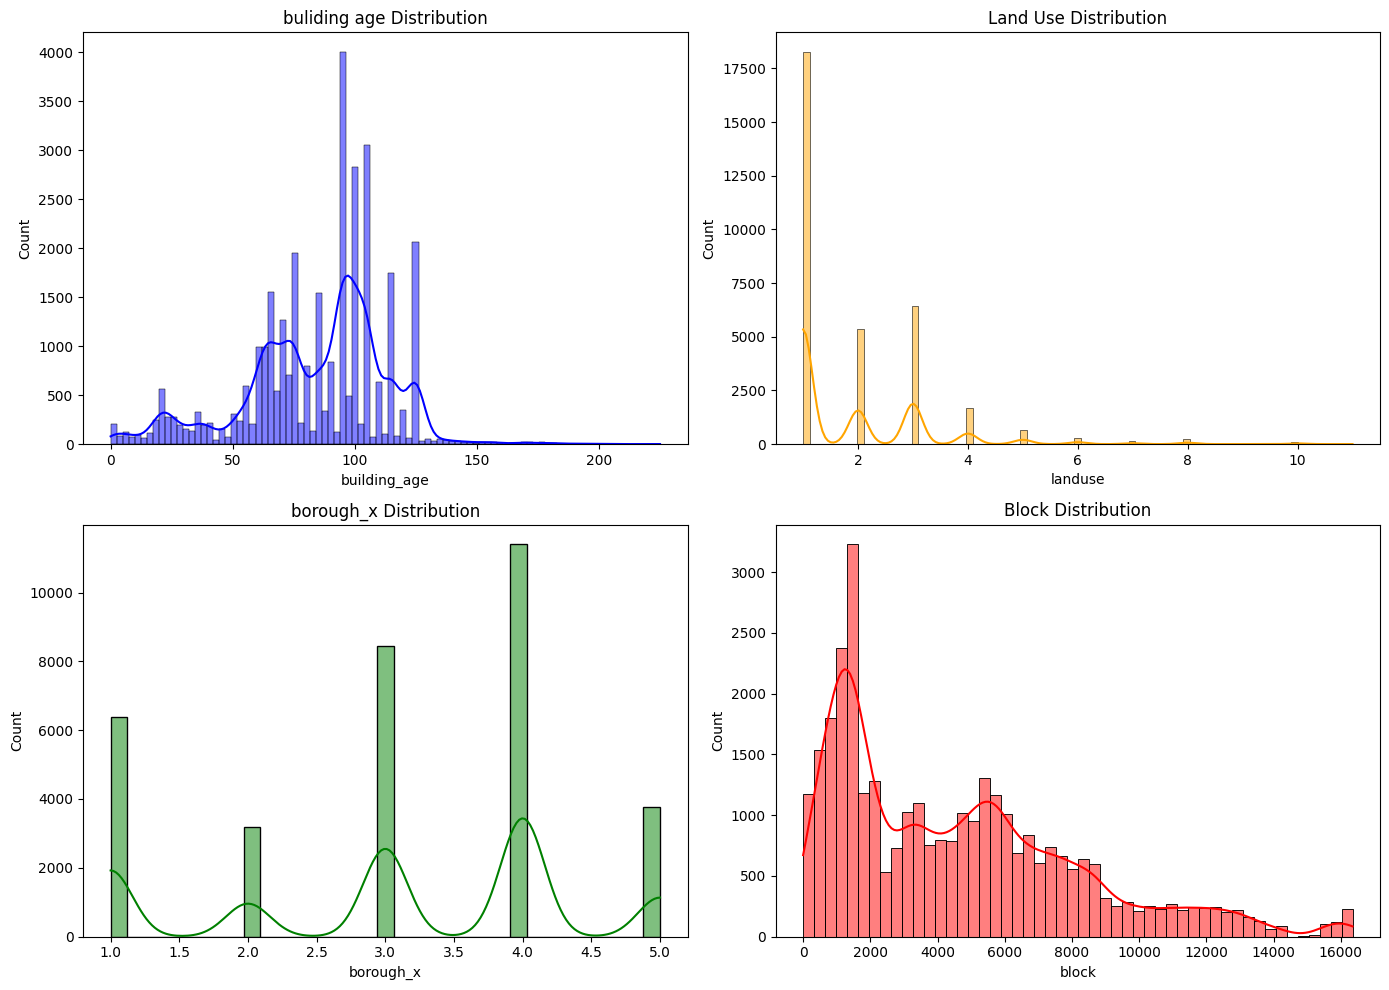

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df_final['building_age'], kde=True, color='blue', ax=axes[0, 0])
axes[0, 0].set_title('buliding age Distribution')

sns.histplot(df_final['landuse'], kde=True, color='orange', ax=axes[0, 1])
axes[0, 1].set_title('Land Use Distribution')

sns.histplot(df_final['borough_x'], kde=True, color='green', ax=axes[1, 0])
axes[1, 0].set_title('borough_x Distribution')

sns.histplot(df_final['block'], kde=True, color='red', ax=axes[1, 1])
axes[1, 1].set_title('Block Distribution')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_final_scaled = scaler.fit_transform(df_final)

In [ ]:
df_final_scaled

array([[ 1.40827166,  0.0535338 , -1.62563051, -1.15101703, -0.72314954],
       [ 1.40827166,  0.0535338 , -1.62563051, -1.15046598,  0.69165919],
       [ 0.71918639,  1.53421887, -1.62563051, -1.15046598,  1.8432477 ],
       ...,
       [-2.07160896, -0.68680874,  1.48511555,  0.7663489 ,  0.03360862],
       [-0.31444152, -0.68680874,  1.48511555,  0.66688503, -0.29541667],
       [-2.00270043,  2.27456141,  1.48511555,  0.74100077, -0.13090485]])

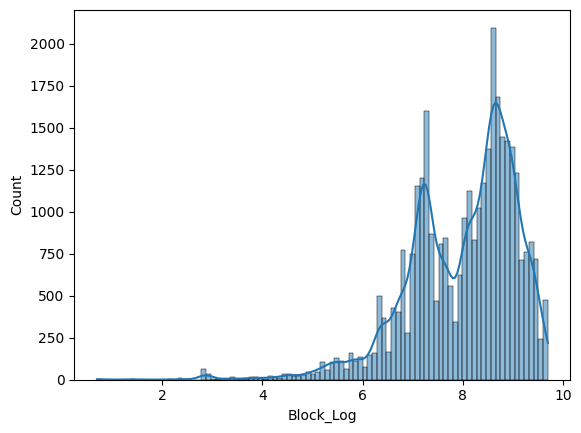

In [ ]:
df['Block_Log'] = np.log1p(df['block'])

# Ab graph check karo
sns.histplot(df['Block_Log'], kde=True)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
X = df_final_scaled[:, :-1]
y = df_final_scaled[:, -1]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
y_pred = lr.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(mse,r2)

0.9013979773680819 0.06633129932519566


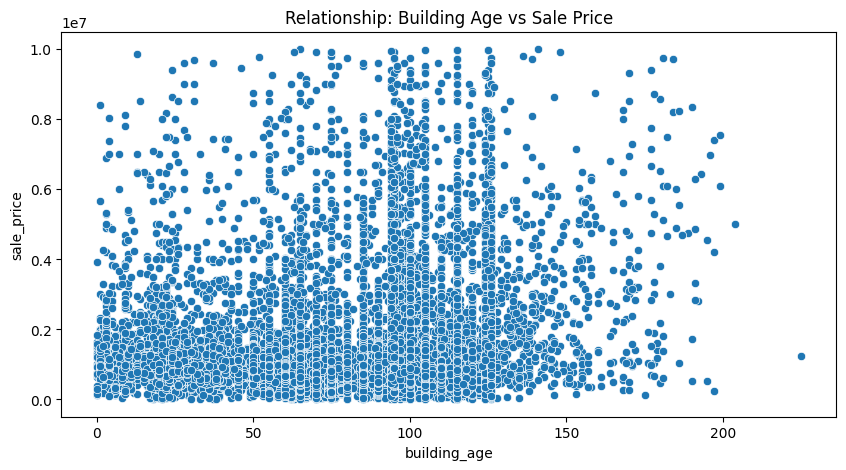

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='building_age', y='sale_price')
plt.title('Relationship: Building Age vs Sale Price')
plt.show()

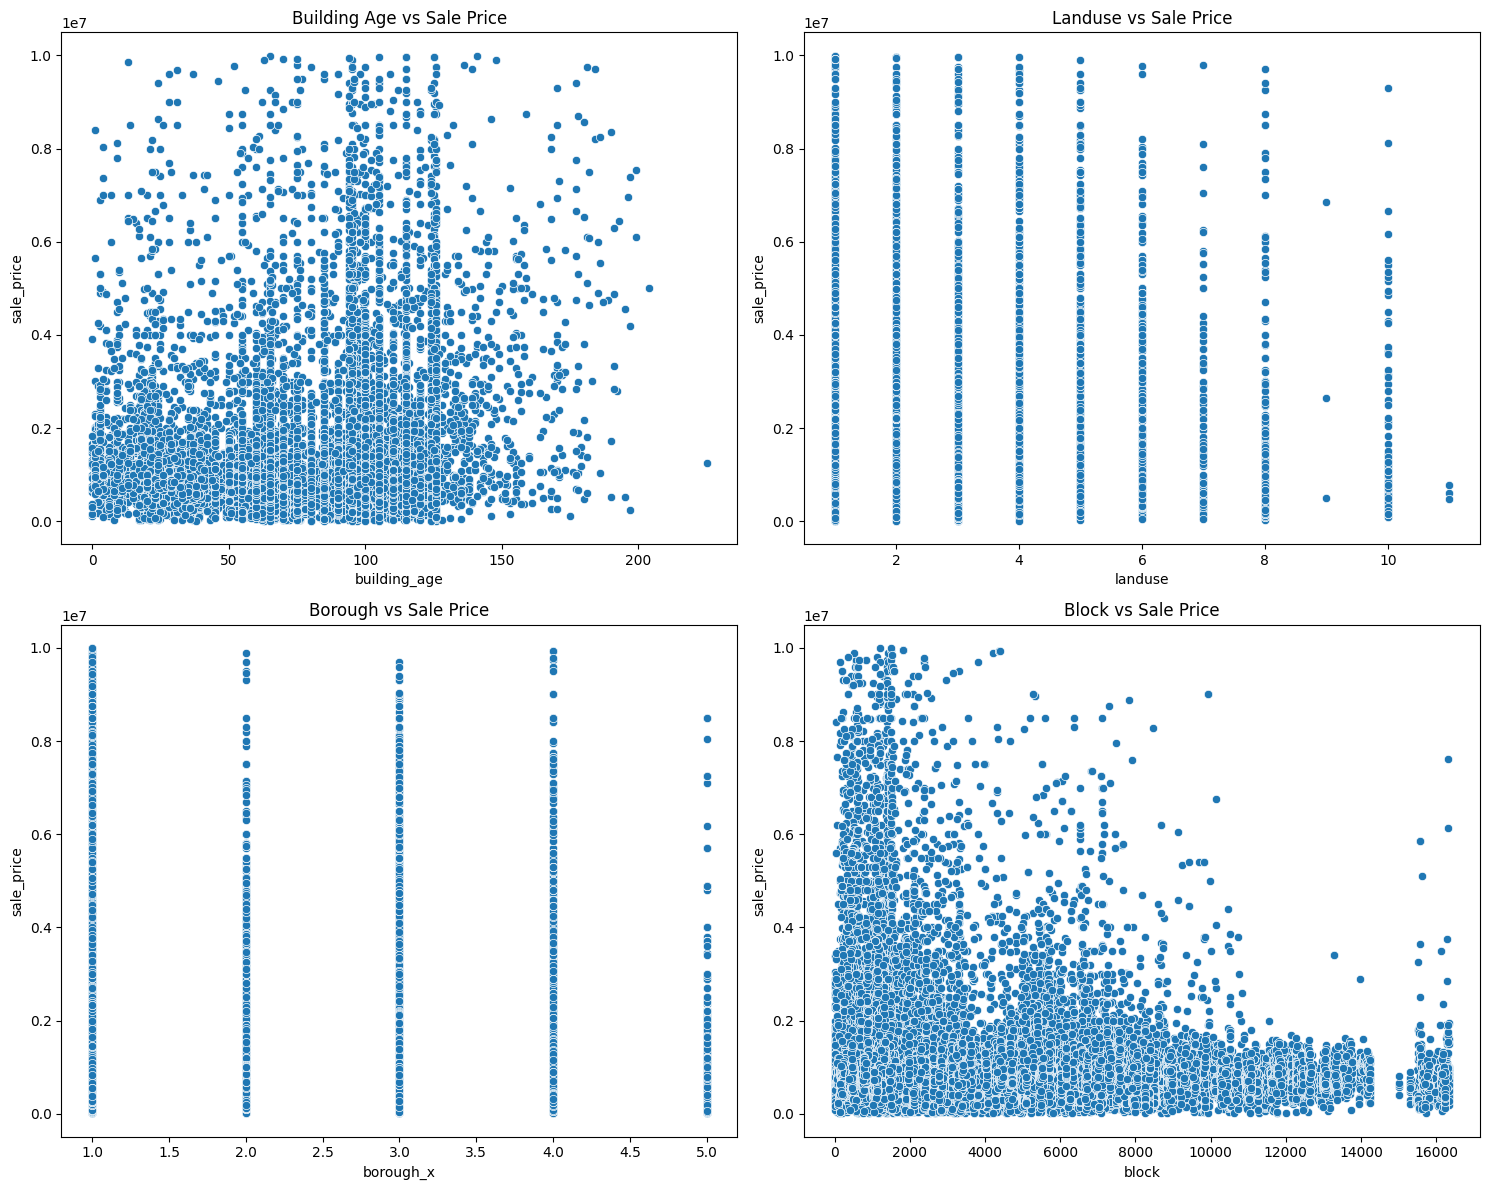

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

sns.scatterplot(ax=axes[0, 0], data=df, x='building_age', y='sale_price')
axes[0, 0].set_title('Building Age vs Sale Price')

sns.scatterplot(ax=axes[0, 1], data=df, x='landuse', y='sale_price')
axes[0, 1].set_title('Landuse vs Sale Price')

sns.scatterplot(ax=axes[1, 0], data=df, x='borough_x', y='sale_price')
axes[1, 0].set_title('Borough vs Sale Price')


sns.scatterplot(ax=axes[1, 1], data=df, x='block', y='sale_price')
axes[1, 1].set_title('Block vs Sale Price')

plt.tight_layout()
plt.show()

# Train and Test

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print(f"New R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"New MSE: {mean_squared_error(y_test, y_pred):.4f}")

New R2 Score: 0.3682
New MSE: 0.6099


In [ ]:
from sklearn.metrics import accuracy_score

# outlier Removing

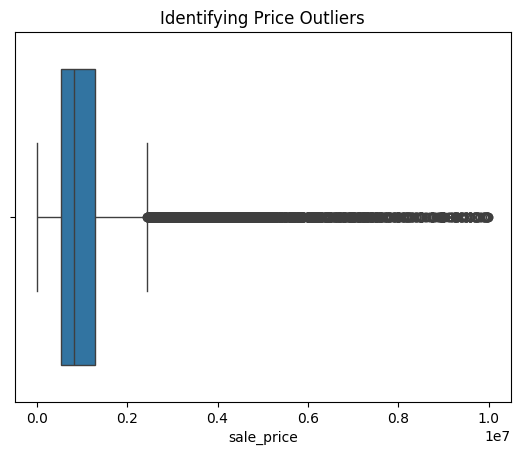

In [ ]:
sns.boxplot(x=df_final['sale_price'])
plt.title('Identifying Price Outliers')
plt.show()

In [ ]:
Q1 = df['sale_price'].quantile(0.25)
Q3 = df['sale_price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df_final[(df['sale_price'] >= lower_bound) & (df['sale_price'] <= upper_bound)]

print(f"Original data size: {len(df)}")
print(f"Cleaned data size: {len(df_clean)}")
print(f"Removed {len(df) - len(df_clean)} outliers.")

Original data size: 33436
Cleaned data size: 30277
Removed 3159 outliers.


/tmp/ipykernel_21333/382561425.py:8: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_clean = df_final[(df['sale_price'] >= lower_bound) & (df['sale_price'] <= upper_bound)]


In [ ]:
X = df_clean.drop(['sale_price'], axis=1)
y = df_clean['sale_price']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=300, max_depth=15, random_state=42)
rf_model.fit(X_train, y_train)

print(f"R2 Score after Outlier Removal: {rf_model.score(X_test, y_test):.4f}")

R2 Score after Outlier Removal: 0.4273


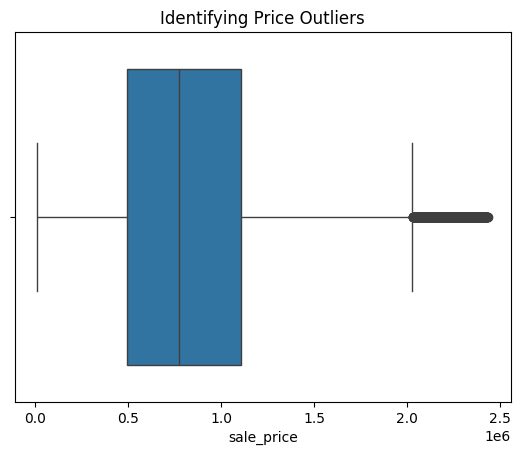

In [ ]:
sns.boxplot(x=df_clean['sale_price'])
plt.title('Identifying Price Outliers')
plt.show()

In [ ]:
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [ ]:
sv = SVR()
dt = DecisionTreeRegressor()
rf = RandomForestRegressor()

In [ ]:
estimators = [('sv',sv), ('dt', dt), ('rf', rf)]

In [ ]:
# from sklearn.model_selection import cross_val_score
# for estimator in estimators:
#   scores = cross_val_score(estimator[1],X,y,scoring='r2',cv=10)
#   print(f'{estimator[0]} : {np.mean(scores)}')


In [ ]:
# from sklearn.ensemble import VotingRegressor
# vr = VotingRegressor(estimators)
# scores = cross_val_score(vr,X,y,scoring='r2',cv=10)
# print("voting Regressor",np.round(np.mean(scores),2))

#Linear Regresson From Scratch

In [ ]:
class MYLR:
  def __init__(self):
    self.m = None
    self.b = None

  def fit(self,X_train,y_train):
    num = 0
    den = 0

    for i in range(X_train.shape[0]):
      num = num + ((X_train[i] - X_train.mean()) * (y_train[i] - y_train.mean()))
      den = den + ((X_train[i] - X_train.mean()) * (X_train[i] - X_train.mean()))

      self.m = num/den
      self.b = y_train.mean() - (self.m*X_train.mean())

    print(self.m)
    print(self.b)

  def predict(self,X_test):
    return self.m * X_test + self.b


In [ ]:
class MYLR_Multiple:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0

        for i in range(self.epochs):
            y_predicted = np.dot(X, self.weights) + self.bias

            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

# Model Checking

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.linear_model import LinearRegression as SklearnLR

# # 1. Generate Data
# np.random.seed(42)
# X = 2 * np.random.rand(100, 2)  # 100 samples, 2 features
# # True weights: w1=4, w2=-3, bias=2
# y = 4 * X[:, 0] - 3 * X[:, 1] + 2 + np.random.randn(100) * 0.5

# # 2. Train Our Model (From Scratch)
# model_scratch = MYLR_Multiple(learning_rate=0.1, epochs=1000)
# model_scratch.fit(X, y)

# # 3. Train Scikit-Learn Model (The benchmark)
# model_sklearn = SklearnLR()
# model_sklearn.fit(X, y)

# # 4. Compare Coefficients
# print(f"Scratch Weights: {model_scratch.weights}, Bias: {model_scratch.bias:.4f}")
# print(f"Sklearn Weights: {model_sklearn.coef_}, Bias: {model_sklearn.intercept_:.4f}")

In [ ]:
df_clean

,building_age,landuse,borough_x,block,sale_price
0,125.0,2.0,1,400,280000
1,125.0,2.0,1,402,2000000
4,105.0,2.0,1,372,655000
5,81.0,4.0,1,373,470000
6,81.0,4.0,1,373,474000
...,...,...,...,...,...
34434,29.0,1.0,5,7316,850000
34435,30.0,1.0,5,7317,855000
34436,24.0,1.0,5,7359,1200000
34437,75.0,1.0,5,6998,800000


In [ ]:
scaler = StandardScaler()
df_clean_scaled = scaler.fit_transform(df_clean)

In [ ]:
y = df_clean_scaled[:,-1]
X = df_clean_scaled[:,0:4]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=300, max_depth=15, random_state=42)
rf_model.fit(X_train, y_train)

print(f"R2 Score after Outlier Removal: {rf_model.score(X_test, y_test):.4f}")

R2 Score after Outlier Removal: 0.4278
